## 데이터 비교 체크용으로 생성한 노트북 파일입니다 삭제할 예정

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 노트북 실행 위치에 관계없이 프로젝트 루트의 data 폴더를 찾음
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "data").exists() else NOTEBOOK_DIR.parent
DATA_DIR = PROJECT_ROOT / "data" / "preprocessed"

X_train = pd.read_csv(DATA_DIR / "X_train.csv")
X_val   = pd.read_csv(DATA_DIR / "X_val.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv")["churn"]
y_val   = pd.read_csv(DATA_DIR / "y_val.csv")["churn"]

print("X_train:", X_train.shape, "| X_val:", X_val.shape)
print("이탈률 - train:", y_train.mean().round(3), "| val:", y_val.mean().round(3))

X_train: (2592, 10) | X_val: (864, 10)
이탈률 - train: 0.494 | val: 0.494


## DUMMY BASELINE

In [12]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
pred = dummy.predict(X_val)
print("Recall:", recall_score(y_val, pred))  # 아마 0 근처 (다수 클래스만 찍으니까)

Recall: 0.0


In [2]:
baseline_model = LGBMClassifier(random_state=42, verbose=-1)
baseline_model.fit(X_train, y_train)

def evaluate(model, X, y, dataset_name):
    """recall을 맨 앞에 두어 팀 평가 기준(Recall 우선)에 맞춤"""
    pred = model.predict(X)
    proba = model.predict_proba(X)[:, 1]
    return {
        "dataset": dataset_name,
        "recall": recall_score(y, pred),
        "precision": precision_score(y, pred),
        "auc": roc_auc_score(y, proba),
        "accuracy": accuracy_score(y, pred),
        "f1": f1_score(y, pred),
    }

baseline_results = pd.DataFrame([
    evaluate(baseline_model, X_train, y_train, "train"),
    evaluate(baseline_model, X_val, y_val, "val"),
])
print(baseline_results.set_index("dataset").T.round(3))

dataset    train    val
recall     0.934  0.656
precision  0.914  0.656
auc        0.980  0.741
accuracy   0.924  0.660
f1         0.923  0.656


In [3]:
tuned_model = LGBMClassifier(
    n_estimators=100,        # 많이 잡아두고 early stopping이 알아서 멈추게 함
    learning_rate=0.03,       # baseline(0.1)보다 조심스럽게 학습
    num_leaves=15,            # baseline(31)보다 트리를 단순하게
    max_depth=5,              # 트리 깊이 제한
    min_child_samples=30,     # 리프 노드 최소 샘플 수 (노이즈 방지)
    reg_alpha=0.1,            # L1 규제
    reg_lambda=0.1,           # L2 규제
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)
tuned_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=0)],
);

tuned_results = pd.DataFrame([
    evaluate(tuned_model, X_train, y_train, "train"),
    evaluate(tuned_model, X_val, y_val, "val"),
])
print(tuned_results.set_index("dataset").T.round(3))

dataset    train    val
recall     0.773  0.721
precision  0.710  0.689
auc        0.817  0.769
accuracy   0.732  0.701
f1         0.740  0.705


In [4]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 8, 63),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": 42,
        "verbose": -1,
    }
    model = LGBMClassifier(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric="auc",
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=0)])
    return roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=100, show_progress_bar=True)

# 확정 모델 재학습 (10개 피처 기준 최종 후보)
best_params_10f = {**study.best_params, "n_estimators": 1000, "random_state": 42, "verbose": -1}
best_model_10f = LGBMClassifier(**best_params_10f)
best_model_10f.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[
        lgb.early_stopping(50, verbose=False),   # verbose=False로 로그 숨김
        lgb.log_evaluation(period=0),
    ],
);

# ── 결과를 표 형태로 깔끔하게 출력 ──────────────────────────
print(f"최고 val AUC: {study.best_value:.4f}  (트리 {best_model_10f.best_iteration_}개 사용)\n")
print("최적 하이퍼파라미터")
print(pd.Series(study.best_params, name="value").round(4).to_string())

  0%|          | 0/100 [00:00<?, ?it/s]

최고 val AUC: 0.7741  (트리 7개 사용)

최적 하이퍼파라미터
learning_rate         0.0114
num_leaves           42.0000
max_depth             4.0000
min_child_samples    18.0000
reg_alpha             0.0050
reg_lambda            0.0047
subsample             0.6623
colsample_bytree      0.6635


In [5]:
print(optuna.__version__)

4.9.0


                feature  importance
            net_revenue          27
           recency_days          24
avg_days_between_orders          19
      distinct_products          11
              frequency           8
            tenure_days           8
  recent_activity_ratio           2
             has_return           1
                  is_uk           0
           is_low_value           0


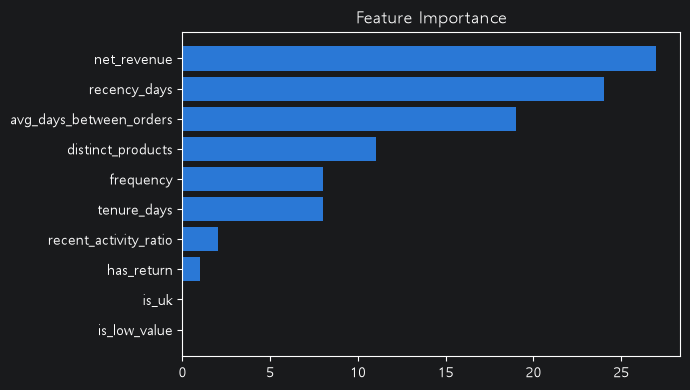

C:\Users\munkyu\Desktop\skn33-2nd-5team\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


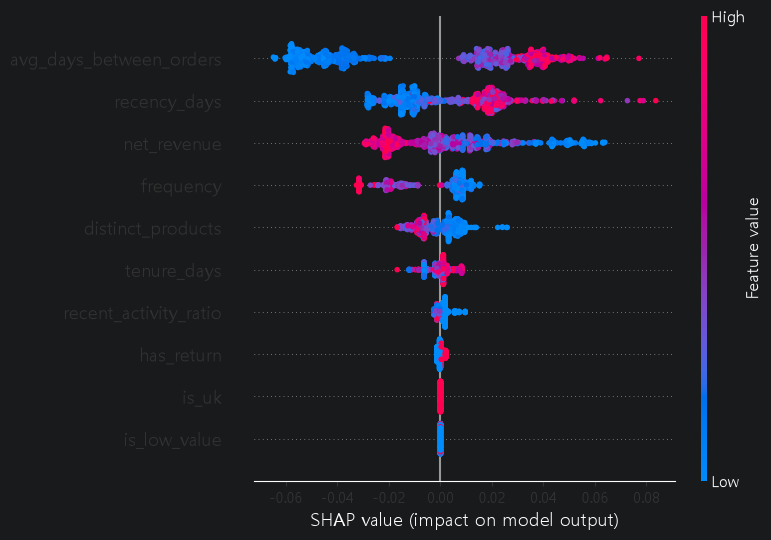

In [6]:
import shap
import matplotlib.pyplot as plt
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_model_10f.feature_importances_,
}).sort_values("importance", ascending=False)
print(importance_df.to_string(index=False))

plt.figure(figsize=(7, 4))
plt.barh(importance_df["feature"][::-1], importance_df["importance"][::-1], color="#2a78d6")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

explainer = shap.TreeExplainer(best_model_10f)
shap_values = explainer.shap_values(X_val)
if isinstance(shap_values, list):
    # LightGBM 이진분류 + 최신 shap 버전에서 [클래스0 배열, 클래스1 배열] 리스트로 반환됨
    shap_values = shap_values[1]  # 양성 클래스(이탈=1) 기준만 사용

shap.summary_plot(shap_values, X_val)

In [7]:
print(shap.__version__)

0.52.0


In [8]:
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.metrics import recall_score, precision_score, roc_auc_score, classification_report

X_train = pd.read_csv("../../data/preprocessed/X_train.csv")
y_train = pd.read_csv("../../data/preprocessed/y_train.csv")["churn"]
X_val = pd.read_csv("../../data/preprocessed/X_val.csv")
y_val = pd.read_csv("../../data/preprocessed/y_val.csv")["churn"]

# 트리 계열이라 다중공선성 걱정 없이 10개 피처 그대로 사용
model = LGBMClassifier(random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_val)
proba = model.predict_proba(X_val)[:, 1]

print("Recall:", round(recall_score(y_val, pred), 3))
print("Precision:", round(precision_score(y_val, pred), 3))
print("AUC:", round(roc_auc_score(y_val, proba), 3))
print(classification_report(y_val, pred))

Recall: 0.656
Precision: 0.656
AUC: 0.741
              precision    recall  f1-score   support

           0       0.66      0.66      0.66       437
           1       0.66      0.66      0.66       427

    accuracy                           0.66       864
   macro avg       0.66      0.66      0.66       864
weighted avg       0.66      0.66      0.66       864



In [9]:
import joblib
from sklearn.preprocessing import StandardScaler

preprocessor = joblib.load(DATA_DIR / "preprocessor.pkl")

def inverse_scale(df, ct):
    """
    ColumnTransformer 내부 단계를 거꾸로 적용해 원래 단위로 복원.
    원본 파일(X_train.csv 등)과 preprocessor.pkl은 읽기만 하고 수정하지 않음 -
    복사본(df.copy())에서만 작업하고, 이후 다시 스케일링해서 원상태로 되돌림.
    """
    df = df.copy()
    for name, transformer, cols in ct.transformers_:
        if isinstance(transformer, str):
            continue
        cols = list(cols)
        if hasattr(transformer, "steps"):  # Pipeline (예: net_revenue의 clip->log->scale)
            values = df[cols].values
            for step_name, step in reversed(transformer.steps):
                if step_name == "scale":
                    values = step.inverse_transform(values)
                elif step_name == "log":
                    values = np.expm1(values)  # log1p의 역연산
            df[cols] = values
        else:
            df[cols] = transformer.inverse_transform(df[cols])
    return df

X_train_orig = inverse_scale(X_train, preprocessor)
X_val_orig   = inverse_scale(X_val, preprocessor)

def add_features(df):
    df = df.copy()
    # 자기 구매 리듬 대비 얼마나 늦었나 (분모 0 방지로 +1)
    df["recency_ratio"] = df["recency_days"] / (df["avg_days_between_orders"] + 1)
    # 주문 1건당 상품 다양성
    df["product_diversity_ratio"] = df["distinct_products"] / df["frequency"]
    # 가입기간 대비 하루 평균 지출 (분모 0 방지로 +1)
    df["revenue_per_day"] = df["net_revenue"] / (df["tenure_days"] + 1)
    return df

X_train_fe = add_features(X_train_orig)
X_val_fe   = add_features(X_val_orig)

continuous_cols = ["recency_days", "frequency", "distinct_products", "net_revenue",
                    "tenure_days", "avg_days_between_orders"]
new_cols = ["recency_ratio", "product_diversity_ratio", "revenue_per_day"]
all_continuous = continuous_cols + new_cols

new_scaler = StandardScaler()
X_train_fe[all_continuous] = new_scaler.fit_transform(X_train_fe[all_continuous])
X_val_fe[all_continuous]   = new_scaler.transform(X_val_fe[all_continuous])

print(f"피처 {X_train.shape[1]}개 -> {X_train_fe.shape[1]}개\n")
print("새로 추가된 피처 (원래 단위 기준, 스케일링 전)")
print(X_train_orig.pipe(add_features)[new_cols].describe().round(2))

피처 10개 -> 13개

새로 추가된 피처 (원래 단위 기준, 스케일링 전)
       recency_ratio  product_diversity_ratio  revenue_per_day
count        2592.00                  2592.00          2592.00
mean            1.40                    16.00             7.38
std             1.54                    15.46            23.53
min             0.00                     0.17             0.00
25%             0.69                     6.50             1.41
50%             1.00                    12.00             2.90
75%             1.79                    20.33             6.50
max            41.83                   164.00           651.92


In [10]:
def objective_fe(trial):
    params = {
        "n_estimators": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 8, 63),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": 42,
        "verbose": -1,
    }
    model = LGBMClassifier(**params)
    model.fit(X_train_fe, y_train, eval_set=[(X_val_fe, y_val)], eval_metric="auc",
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=0)])
    return roc_auc_score(y_val, model.predict_proba(X_val_fe)[:, 1])

study_fe = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study_fe.optimize(objective_fe, n_trials=100, show_progress_bar=True)

# 13개 피처 기준 최종 모델 재학습
best_params_13f = {**study_fe.best_params, "n_estimators": 1000, "random_state": 42, "verbose": -1}
model_fe = LGBMClassifier(**best_params_13f)
model_fe.fit(
    X_train_fe, y_train,
    eval_set=[(X_val_fe, y_val)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=0)],
);

# ── 팀 평가 기준(Recall 우선)으로 두 후보(10개 vs 13개) 비교 ──────
def eval_recall_first(model, X, y, name):
    pred = model.predict(X)
    proba = model.predict_proba(X)[:, 1]
    return {
        "model": name,
        "recall": recall_score(y, pred),
        "precision": precision_score(y, pred),
        "auc": roc_auc_score(y, proba),
    }

comparison = pd.DataFrame([
    eval_recall_first(best_model_10f, X_val, y_val, "10개 피처(3단계)"),
    eval_recall_first(model_fe, X_val_fe, y_val, "13개 피처(5-1단계)"),
])
print(comparison.set_index("model").round(4))

  0%|          | 0/100 [00:00<?, ?it/s]

               recall  precision     auc
model                                   
10개 피처(3단계)    0.6628     0.7111  0.7741
13개 피처(5-1단계)  0.6511     0.7240  0.7755


In [11]:
from sklearn.model_selection import StratifiedKFold, train_test_split

X_pool = pd.concat([X_train, X_val], ignore_index=True)
y_pool = pd.concat([y_train, y_val], ignore_index=True)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []

for fold, (tr_idx, ho_idx) in enumerate(skf.split(X_pool, y_pool), 1):
    X_fold_train, X_fold_holdout = X_pool.iloc[tr_idx], X_pool.iloc[ho_idx]
    y_fold_train, y_fold_holdout = y_pool.iloc[tr_idx], y_pool.iloc[ho_idx]

    # early stopping용으로 fold의 학습 파트를 다시 80/20으로 쪼갬
    # (10%는 조각이 너무 작아 early stopping이 불안정했음 -> 20%로 확대해 안정화)
    X_tr, X_es, y_tr, y_es = train_test_split(
        X_fold_train, y_fold_train, test_size=0.2, stratify=y_fold_train, random_state=42
    )

    model = LGBMClassifier(n_estimators=1000, **study.best_params, random_state=42, verbose=-1)
    model.fit(X_tr, y_tr, eval_set=[(X_es, y_es)], eval_metric="auc",
              callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(period=0)])

    pred = model.predict(X_fold_holdout)
    proba = model.predict_proba(X_fold_holdout)[:, 1]
    result = {
        "fold": fold,
        "recall": recall_score(y_fold_holdout, pred),
        "precision": precision_score(y_fold_holdout, pred),
        "auc": roc_auc_score(y_fold_holdout, proba),
        "n_trees": model.best_iteration_,
    }
    fold_results.append(result)
    print(f"Fold {fold}: recall={result['recall']:.4f}  precision={result['precision']:.4f}  "
          f"auc={result['auc']:.4f}  (트리 {result['n_trees']}개)")

fold_df = pd.DataFrame(fold_results).set_index("fold")
print("\n5-fold 평균 ± 표준편차")
print(fold_df[["recall", "precision", "auc"]].agg(["mean", "std"]).round(4))

Fold 1: recall=0.7398  precision=0.7008  auc=0.7819  (트리 66개)
Fold 2: recall=0.6784  precision=0.6884  auc=0.7674  (트리 15개)
Fold 3: recall=0.7390  precision=0.6811  auc=0.7672  (트리 552개)
Fold 4: recall=0.7302  precision=0.6898  auc=0.7729  (트리 32개)
Fold 5: recall=0.6481  precision=0.6994  auc=0.7648  (트리 6개)

5-fold 평균 ± 표준편차
      recall  precision     auc
mean  0.7071     0.6919  0.7708
std   0.0416     0.0082  0.0069


## 스태킹 - 소프트보팅

In [13]:
import pandas as pd
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import recall_score, precision_score, roc_auc_score
from sklearn.model_selection import cross_validate

X_train = pd.read_csv("../../data/preprocessed/X_train.csv")
y_train = pd.read_csv("../../data/preprocessed/y_train.csv")["churn"]
X_val = pd.read_csv("../../data/preprocessed/X_val.csv")
y_val = pd.read_csv("../../data/preprocessed/y_val.csv")["churn"]

rf_final = RandomForestClassifier(n_estimators=400, max_depth=4, min_samples_leaf=5, random_state=42)

xgb_final = XGBClassifier(
    learning_rate=0.08694766035576398,
    max_depth=4,
    min_child_weight=11,
    reg_alpha=0.006604000109077785,
    reg_lambda=1.1583720234948063,
    subsample=0.6911753101757742,
    colsample_bytree=0.7272290625196041,
    n_estimators=35,   # 6단계에서 확인된 best_iteration 근처 값으로 고정 (K-fold 안정성 위해 early stopping 대신 고정)
    random_state=42,
)

voting = VotingClassifier(
    estimators=[("rf", rf_final), ("xgb", xgb_final)],
    voting="soft"   # 확률 평균 (hard는 다수결 라벨 투표)
)
voting.fit(X_train, y_train)

pred = voting.predict(X_val)
proba = voting.predict_proba(X_val)[:, 1]

print("Val Recall:", round(recall_score(y_val, pred), 3))
print("Val Precision:", round(precision_score(y_val, pred), 3))
print("Val AUC:", round(roc_auc_score(y_val, proba), 3))

Val Recall: 0.742
Val Precision: 0.686
Val AUC: 0.772


In [14]:
voting_weighted = VotingClassifier(
    estimators=[("rf", rf_final), ("xgb", xgb_final)],
    voting="soft",
    weights=[2, 1]   # RF에 가중치 2배
)
voting_weighted.fit(X_train, y_train)
pred = voting_weighted.predict(X_val)
proba = voting_weighted.predict_proba(X_val)[:, 1]
print("Recall:", round(recall_score(y_val, pred), 3))
print("Precision:", round(precision_score(y_val, pred), 3))
print("AUC:", round(roc_auc_score(y_val, proba), 3))

Recall: 0.738
Precision: 0.68
AUC: 0.771


In [15]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stacking = StackingClassifier(
    estimators=[("rf", rf_final), ("xgb", xgb_final)],
    final_estimator=LogisticRegression(random_state=42),
    cv=5
)
stacking.fit(X_train, y_train)
pred = stacking.predict(X_val)
proba = stacking.predict_proba(X_val)[:, 1]
print("Recall:", round(recall_score(y_val, pred), 3))
print("Precision:", round(precision_score(y_val, pred), 3))
print("AUC:", round(roc_auc_score(y_val, proba), 3))

Recall: 0.731
Precision: 0.698
AUC: 0.772


In [22]:
# Recall이 0.85에 가장 가까운 지점 찾기 (Recall이 너무 낮아지기 직전 경계)
target_recall = 0.85
idx = (threshold_df["recall"] - target_recall).abs().idxmin()
print(threshold_df.loc[idx])

print("\n--- Recall 0.80~0.90 구간 전체 ---")
print(threshold_df[(threshold_df["recall"] >= 0.80) & (threshold_df["recall"] <= 0.90)]
      .drop_duplicates(subset="recall")
      .sort_values("recall"))

threshold    0.367897
precision    0.623711
recall       0.850117
Name: 281, dtype: float64

--- Recall 0.80~0.90 구간 전체 ---
     threshold  precision    recall
348   0.438451   0.664078  0.800937
347   0.438374   0.664729  0.803279
346   0.436988   0.665377  0.805621
343   0.435441   0.663462  0.807963
342   0.434083   0.664107  0.810304
340   0.432362   0.663480  0.812646
336   0.430704   0.660342  0.814988
335   0.429864   0.660985  0.817330
332   0.424031   0.659134  0.819672
329   0.422744   0.657303  0.822014
327   0.422044   0.656716  0.824356
326   0.420759   0.657356  0.826698
323   0.417108   0.655556  0.829040
320   0.412725   0.653775  0.831382
307   0.391948   0.640288  0.833724
303   0.389152   0.637500  0.836066
301   0.386871   0.637011  0.838407
300   0.386551   0.637655  0.840749
299   0.385942   0.638298  0.843091
285   0.371799   0.624567  0.845433
282   0.369168   0.623064  0.847775
281   0.367897   0.623711  0.850117
278   0.366703   0.622222  0.852459
277   0.3664

In [23]:
print("\n--- Recall 0.75~0.80 구간 ---")
print(threshold_df[(threshold_df["recall"] >= 0.75) & (threshold_df["recall"] <= 0.80)]
      .drop_duplicates(subset="recall")
      .sort_values("recall"))


--- Recall 0.75~0.80 구간 ---
     threshold  precision    recall
386   0.483664   0.672956  0.751756
383   0.482476   0.670833  0.754098
382   0.479963   0.671518  0.756440
381   0.479005   0.672199  0.758782
380   0.478872   0.672878  0.761124
377   0.475621   0.670782  0.763466
376   0.474680   0.671458  0.765808
375   0.474439   0.672131  0.768150
372   0.466456   0.670061  0.770492
371   0.465459   0.670732  0.772834
366   0.460044   0.665996  0.775176
365   0.459968   0.666667  0.777518
364   0.459064   0.667335  0.779859
363   0.456512   0.668000  0.782201
362   0.455728   0.668663  0.784543
361   0.454925   0.669323  0.786885
358   0.450358   0.667327  0.789227
356   0.449442   0.666667  0.791569
355   0.448013   0.667323  0.793911
354   0.446589   0.667976  0.796253
351   0.443207   0.666016  0.798595


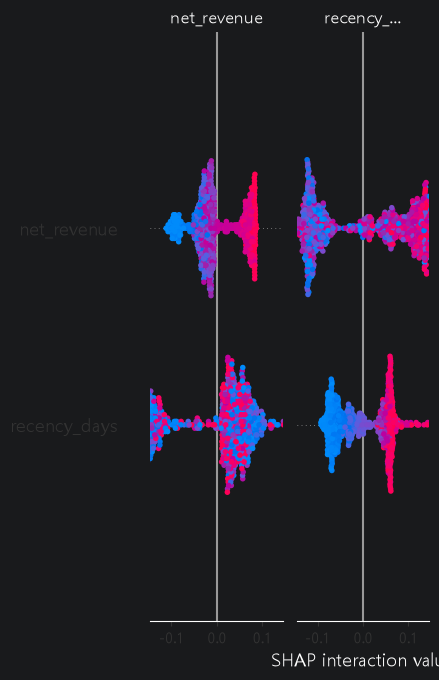

In [24]:
import shap
import matplotlib.pyplot as plt
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

explainer = shap.TreeExplainer(rf_final)
shap_values = explainer.shap_values(X_val)
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # 이탈(1) 클래스 기준

shap.summary_plot(shap_values, X_val)

<class 'numpy.ndarray'>


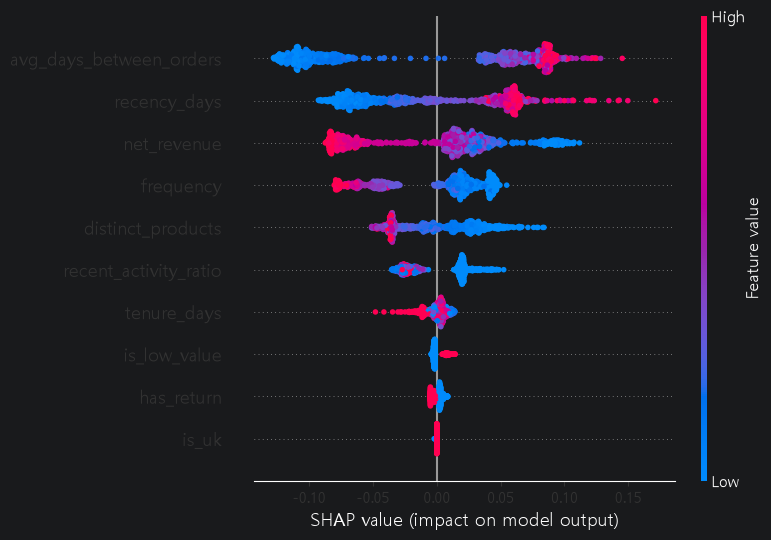

In [25]:
import shap
import matplotlib.pyplot as plt
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

explainer = shap.TreeExplainer(rf_final)
shap_values = explainer.shap_values(X_val)

print(type(shap_values))  # 확인용 — list인지 array인지
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values = shap_values[:, :, 1]  # (샘플, 피처, 클래스) 형태인 경우

plt.figure()
shap.summary_plot(shap_values, X_val, show=True)

In [26]:
import pandas as pd
import numpy as np

proba_rf = rf_final.predict_proba(X_val)[:, 1]

decile_df = pd.DataFrame({"proba": proba_rf, "actual": y_val.values})
decile_df["decile"] = pd.qcut(decile_df["proba"], 10, labels=False, duplicates="drop")
decile_df["decile"] = 9 - decile_df["decile"]  # 0이 최상위 위험군이 되도록 뒤집기

summary = decile_df.groupby("decile").agg(
    고객수=("actual", "size"),
    실제이탈률=("actual", "mean"),
).sort_index()

base_rate = y_val.mean()
summary["Lift"] = (summary["실제이탈률"] / base_rate).round(2)

print(summary.round(3))

# Top-K Capture: 상위 K% 안에 전체 이탈자의 몇 %가 잡히는지
decile_df_sorted = decile_df.sort_values("proba", ascending=False).reset_index(drop=True)
total_churners = decile_df["actual"].sum()
for k in [10, 20, 30, 50]:
    n = int(len(decile_df_sorted) * k / 100)
    captured = decile_df_sorted.iloc[:n]["actual"].sum()
    print(f"상위 {k}%: 이탈자 {captured}/{total_churners}명 포착 ({100*captured/total_churners:.1f}%)")

        고객수  실제이탈률  Lift
decile                  
0        87  0.805  1.63
1        86  0.709  1.44
2        86  0.767  1.55
3        87  0.632  1.28
4        86  0.512  1.04
5        86  0.570  1.15
6        87  0.402  0.81
7        86  0.244  0.49
8        86  0.233  0.47
9        87  0.069  0.14
상위 10%: 이탈자 70/427명 포착 (16.4%)
상위 20%: 이탈자 131/427명 포착 (30.7%)
상위 30%: 이탈자 197/427명 포착 (46.1%)
상위 50%: 이탈자 296/427명 포착 (69.3%)


In [27]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
import joblib

# 지금 학습된 rf_final, preprocessor를 그대로 저장 (프로토타입용 — 나중에 최종 확정본으로 교체)
joblib.dump(rf_final, "../lsy/rf_prototype.joblib")
joblib.dump(preprocessor, "../lsy/preprocessor_prototype.joblib")

print("저장 완료")

저장 완료


In [29]:
print(rf_final.feature_names_in_)

['net_revenue' 'recency_days' 'frequency' 'distinct_products'
 'tenure_days' 'avg_days_between_orders' 'is_low_value' 'is_uk'
 'has_return' 'recent_activity_ratio']


In [32]:
import pandas as pd
rate = snapshot.groupby(pd.cut(snapshot["recency_days"], bins=10))["churn"].agg(["mean", "count"])
print(rate)

                    mean  count
recency_days                   
(-0.364, 36.4]  0.252004   1123
(36.4, 72.8]    0.365812    585
(72.8, 109.2]   0.467368    475
(109.2, 145.6]  0.543210    324
(145.6, 182.0]  0.618123    309
(182.0, 218.4]  0.655963    218
(218.4, 254.8]  0.701863    161
(254.8, 291.2]  0.691429    350
(291.2, 327.6]  0.703863    466
(327.6, 364.0]  0.718447    309


In [31]:
import pandas as pd
from src.features import make_snapshot

snapshot = make_snapshot(pd.Timestamp("2011-09-10"), window=90)
print(snapshot.shape)

(4320, 16)
